In [1]:
import numpy as np
import feature_engineering_scaling_new as fes
from tensorflow.keras.models import load_model
import tensorflow as tf
from tensorflow.keras.layers import Layer

2025-02-18 13:42:06.099881: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-18 13:42:06.883302: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-18 13:42:08.891094: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from tensorflow.keras.utils import to_categorical

In [3]:
import RNN_preprocessing_whole as rp

In [4]:
class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def call(self, inputs):
        """
        Applies attention mechanism to the inputs.

        Args:
            inputs: Tensor of shape (batch_size, seq_length, features).

        Returns:
            Tensor of shape (batch_size, features).
        """
        query = inputs  # Use the same input as query, key, and value
        key = inputs
        value = inputs

        # Compute attention scores
        scores = tf.matmul(query, key, transpose_b=True)  # Shape: (batch, seq_length, seq_length)
        scores = tf.nn.softmax(scores, axis=-1)  # Normalize scores

        # Weighted sum of the values
        context = tf.matmul(scores, value)  # Shape: (batch, seq_length, features)

        return context

In [5]:
# Load the saved models
model = load_model("model_bidirec_lstm_w_time.h5", custom_objects={"Attention": Attention})

2025-02-18 13:42:56.155304: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [6]:
y_pred = model.predict(rp.X_seq_test) 

2025-02-18 13:42:59.203689: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 309265200 exceeds 10% of free system memory.
2025-02-18 13:43:00.867845: W tensorflow/core/grappler/costs/op_level_cost_estimator.cc:693] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "CPU" vendor: "GenuineIntel" model: "106" frequency: 3093 num_cores: 4 environment { key: "cpu_instruction_set" value: "AVX SSE, SSE2, SSE3, SSSE3, SSE4.1, SSE4.2" } environment { key: "eigen" value: "3.4.90" } l1_cache_size: 32768 l2_cache_size: 262144 l3_cache_size: 3145728 memory_size: 268435456 } outputs { dtype: DT_FLOAT shape { unknown_rank: true } }


40269/40269 [==============================] - 243s 6ms/step


2025-02-18 13:47:30.072004: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 515442000 exceeds 10% of free system memory.


In [7]:
from sklearn.metrics import confusion_matrix, classification_report

In [8]:
#convert predictions to class labels
y_pred_classes = np.argmax(y_pred, axis=2)

# Convert one-hot encoded true labels back to class labels
y_test_classes = np.argmax(rp.y_seq_test, axis=2)

In [9]:
# Reshape or flatten the arrays
y_test_classes_flat = y_test_classes.reshape(-1)  # Flatten y_test_classes1
y_pred_classes_flat = y_pred_classes.reshape(-1)  # Flatten y_pred_classes1

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

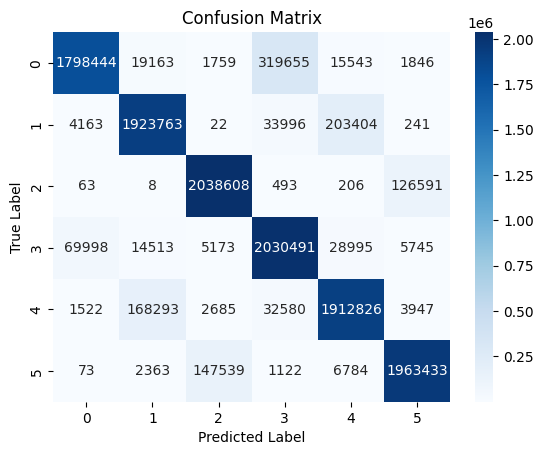

In [11]:
# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test_classes_flat, y_pred_classes_flat)

# Plot the confusion matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [12]:
classification = classification_report(y_test_classes_flat, y_pred_classes_flat)
print("Classification Report:\n")
print(classification)

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.83      0.89   2156410
           1       0.90      0.89      0.90   2165589
           2       0.93      0.94      0.93   2165969
           3       0.84      0.94      0.89   2154915
           4       0.88      0.90      0.89   2121853
           5       0.93      0.93      0.93   2121314

    accuracy                           0.91  12886050
   macro avg       0.91      0.91      0.91  12886050
weighted avg       0.91      0.91      0.91  12886050



In [13]:
from collections import Counter

def signal_detection_metrics(test_classes, pred_classes, signal_classes):
    """
    Calculate the following metrics for each specified class:
    1) Percentage of actual signal events detected w.r.t total signal events.
    2) Percentage of actual signal detected w.r.t. the predicted signal events.
    3) Breakdown of misclassified predictions for each class.
    4) Total number of events classified as the given class.

    Parameters:
    - test_classes: Array-like, ground truth labels
    - pred_classes: Array-like, predicted labels
    - signal_classes: int or list, class/classes for which the metrics should be computed

    Returns:
    - A dictionary containing results for each class.
    """
    
    # Ensure signal_classes is a list
    if isinstance(signal_classes, int):
        signal_classes = [signal_classes]
    
    # Convert to NumPy arrays for easier computation
    test_classes = np.array(test_classes)
    pred_classes = np.array(pred_classes)

    results = {}

    for cls in signal_classes:
        # True Positives (TP): cases where both test and pred match the class
        tp = np.sum((test_classes == cls) & (pred_classes == cls))
        
        # Total actual signal events for the class
        total_signal_events = np.sum(test_classes == cls)
        
        # Total predicted signal events for the class
        total_predicted_signal = np.sum(pred_classes == cls)

        # Compute percentages
        percentage_actual_signal_detected = (tp / total_signal_events * 100) if total_signal_events > 0 else 0
        percentage_detected_signal_accuracy = (tp / total_predicted_signal * 100) if total_predicted_signal > 0 else 0

        # Misclassification breakdown: Find what other classes were mistaken as this class
        misclassified_counts = Counter(test_classes[pred_classes == cls])
        if cls in misclassified_counts:
            del misclassified_counts[cls]  # Remove true positives from misclassification count

        # Convert misclassification counts to percentages
        misclassification_percentages = {other_cls: (count / total_predicted_signal * 100) 
                                         for other_cls, count in misclassified_counts.items()}

        # Store results
        results[cls] = {
            "Total events classified as this class": total_predicted_signal,
            "Percentage of actual signal events detected": percentage_actual_signal_detected,
            "Percentage of detected signal accuracy": percentage_detected_signal_accuracy,
            "Misclassification breakdown (%)": misclassification_percentages
        }

    # Print results
    for cls, metrics in results.items():
        print(f"\nResults for class {cls}:")
        print(f"  - Total events classified as this class: {metrics['Total events classified as this class']}")
        print(f"  - Percentage of actual signal events detected: {metrics['Percentage of actual signal events detected']:.2f}%")
        print(f"  - Percentage of detected signal accuracy: {metrics['Percentage of detected signal accuracy']:.2f}%")

        if metrics["Misclassification breakdown (%)"]:
            print(f"  - Misclassified as other classes:")
            for mis_cls, mis_perc in metrics["Misclassification breakdown (%)"].items():
                print(f"    - Class {mis_cls}: {mis_perc:.2f}%")

    return results

In [14]:
result = signal_detection_metrics(y_test_classes_flat, y_pred_classes_flat, [1, 2, 4, 5])
print(result)


Results for class 1:
  - Total events classified as this class: 2128103
  - Percentage of actual signal events detected: 88.83%
  - Percentage of detected signal accuracy: 90.40%
  - Misclassified as other classes:
    - Class 4: 7.91%
    - Class 3: 0.68%
    - Class 0: 0.90%
    - Class 5: 0.11%
    - Class 2: 0.00%

Results for class 2:
  - Total events classified as this class: 2195786
  - Percentage of actual signal events detected: 94.12%
  - Percentage of detected signal accuracy: 92.84%
  - Misclassified as other classes:
    - Class 5: 6.72%
    - Class 3: 0.24%
    - Class 0: 0.08%
    - Class 4: 0.12%
    - Class 1: 0.00%

Results for class 4:
  - Total events classified as this class: 2167758
  - Percentage of actual signal events detected: 90.15%
  - Percentage of detected signal accuracy: 88.24%
  - Misclassified as other classes:
    - Class 1: 9.38%
    - Class 3: 1.34%
    - Class 0: 0.72%
    - Class 5: 0.31%
    - Class 2: 0.01%

Results for class 5:
  - Total event

# Functions

In [15]:
def calculate_time_differences_for_pair(X_seq_test, label_sequences, event_pair):
    """
    Calculate time differences between a given event pair from sequences.

    Parameters
    ----------
    X_seq_test : np.ndarray
        Array of shape (num_sequences, sequence_length, features). 
        The time information is assumed to be at column index 4.
    label_sequences : np.ndarray
        Array of shape (num_sequences, sequence_length) containing the labels.
    event_pair : tuple
        A tuple (start_event, end_event) specifying the event pair.

    Returns
    -------
    all_diffs : list of lists
        Each inner list contains the time differences for valid (start_event → end_event) pairs in that sequence.
    """
    start_event, end_event = event_pair
    all_diffs = []
    for seq in range(X_seq_test.shape[0]):
        time_diffs = X_seq_test[seq, :, 4]
        labels = label_sequences[seq]
        seq_diffs = []
        i = 0
        while i < len(labels) - 1:
            if labels[i] == start_event and labels[i + 1] == end_event:
                diff = time_diffs[i + 1] - time_diffs[i]
                seq_diffs.append(diff)
                i += 2  # skip the used pair
            else:
                i += 1
        all_diffs.append(seq_diffs)
    return all_diffs


In [16]:
def calculate_correct_time_differences(X_seq_test, y_pred, y_true, event_pair):
    """
    Calculate time differences for correctly predicted event pairs.

    A pair is considered correctly predicted if both events in the prediction match the ground truth.

    Parameters
    ----------
    X_seq_test : np.ndarray
        Array of shape (num_sequences, sequence_length, features). Time is at column index 4.
    y_pred : np.ndarray
        Predicted labels of shape (num_sequences, sequence_length).
    y_true : np.ndarray
        Ground truth labels of shape (num_sequences, sequence_length).
    event_pair : tuple
        A tuple (start_event, end_event) specifying the event pair.

    Returns
    -------
    correct_diffs : list of lists
        Each inner list contains time differences for correctly predicted pairs in that sequence.
    """
    start_event, end_event = event_pair
    correct_diffs = []
    for seq in range(X_seq_test.shape[0]):
        time_diffs = X_seq_test[seq, :, 4]
        pred_labels = y_pred[seq]
        true_labels = y_true[seq]
        seq_diffs = []
        i = 0
        while i < len(true_labels) - 1:
            if (pred_labels[i] == true_labels[i] and pred_labels[i + 1] == true_labels[i + 1] and 
                true_labels[i] == start_event and true_labels[i + 1] == end_event):
                seq_diffs.append(time_diffs[i + 1] - time_diffs[i])
                i += 2  # skip to next pair
            else:
                i += 1
        correct_diffs.append(seq_diffs)
    return correct_diffs

In [17]:
def calculate_incorrect_time_differences(X_seq_test, y_pred, y_true, event_pair):
    """
    Calculate time differences for ground truth event pairs that were incorrectly predicted.

    A pair is considered incorrectly predicted if the ground truth has (start_event → end_event)
    but the predictions do not match this pair.

    Parameters
    ----------
    X_seq_test : np.ndarray
        Array of shape (num_sequences, sequence_length, features). Time is at column index 4.
    y_pred : np.ndarray
        Predicted labels of shape (num_sequences, sequence_length).
    y_true : np.ndarray
        Ground truth labels of shape (num_sequences, sequence_length).
    event_pair : tuple
        A tuple (start_event, end_event) specifying the event pair.

    Returns
    -------
    incorrect_diffs : list of lists
        Each inner list contains time differences for incorrectly predicted pairs in that sequence.
    """
    start_event, end_event = event_pair
    incorrect_diffs = []
    for seq in range(X_seq_test.shape[0]):
        time_diffs = X_seq_test[seq, :, 4]
        pred_labels = y_pred[seq]
        true_labels = y_true[seq]
        seq_diffs = []
        i = 0
        while i < len(true_labels) - 1:
            # Check if there is a valid ground truth pair
            #if true_labels[i] == start_event and true_labels[i + 1] == end_event:
                # If predicted pair does not match the ground truth pair, record the time diff
            if not (pred_labels[i] == start_event and pred_labels[i + 1] == end_event):
                seq_diffs.append(time_diffs[i + 1] - time_diffs[i])
                i += 2  # skip non-overlapping pair
            else:
                i += 1
        incorrect_diffs.append(seq_diffs)
    return incorrect_diffs

In [18]:
def flatten_differences(diff_lists):
    """
    Flatten a list of lists of time differences into a single list.

    Parameters
    ----------
    diff_lists : list of lists
        Nested list of time differences.

    Returns
    -------
    flattened : list
        A single list containing all time differences.
    """
    return [diff for seq in diff_lists for diff in seq]

In [57]:
def plot_histogram(data, title, xlabel, ylabel, xlim=None, ylim=None, bins=100, alpha=0.7):
    """
    Plot a histogram of the data.

    Parameters
    ----------
    data : list or array-like
        Data values to plot.
    title : str
        Title of the plot.
    xlabel : str
        X-axis label.
    ylabel : str
        Y-axis label.
    xlim : tuple, optional
        Limits for the x-axis (e.g., (0, 0.001)).
    bins : int, optional
        Number of bins in the histogram.
    alpha : float, optional
        Transparency level for the histogram bars.
    """
    plt.figure(figsize=(10, 6))
    plt.hist(data, bins=bins, alpha=alpha)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)
    plt.tight_layout()
    plt.show()


# Bi214 (Raw Preds)

In [20]:
# For events 1 and 2:
event_pair_1_2 = (1, 2)

# Calculate time differences for predicted sequences (all pairs)
all_result_diffs = calculate_time_differences_for_pair(rp.X_seq_test, y_pred_classes, event_pair_1_2)
flattened_diffs = flatten_differences(all_result_diffs)
# Apply threshold if needed
threshold = 0.001
values_above_threshold = [x for x in flattened_diffs if x > threshold]
print("Predicted values greater than", threshold, ":", values_above_threshold)

Predicted values greater than 0.001 : [0.0014021992683410645, 0.0014491006731987, 0.0016923993825912476, 0.0010488927364349365, 0.0011337026953697205, 0.001220904290676117, 0.0013361945748329163, 0.0011233985424041748, 0.001046702265739441, 0.0010794028639793396, 0.0013380944728851318, 0.001010105013847351, 0.001354992389678955, 0.0012397989630699158, 0.0012561976909637451, 0.0011797994375228882, 0.0010315030813217163, 0.0010160058736801147, 0.001041896641254425, 0.0010137036442756653, 0.0012058019638061523, 0.5466848015785217, 0.0011689066886901855, 0.0010104924440383911, 0.0010986998677253723, 0.0010361969470977783, 0.0016125887632369995, 0.0010151118040084839, 0.0010542050004005432, 0.0013686120510101318, 0.0013836026191711426, 0.0015624016523361206, 0.0011214986443519592, 0.0017047002911567688, 0.0011684000492095947, 0.0013274997472763062, 0.0011559054255485535, 0.0010123029351234436, 0.0011618956923484802, 0.0010084062814712524, 0.0011693984270095825, 0.0011250004172325134, 0.0012

In [21]:
# Similarly, for the ground truth:
all_result_diffs_real = calculate_time_differences_for_pair(rp.X_seq_test, y_test_classes, event_pair_1_2)
flattened_diffs_real = flatten_differences(all_result_diffs_real)
values_above_threshold_real = [x for x in flattened_diffs_real if x > threshold]
print("Ground truth values greater than", threshold, ":", values_above_threshold_real)

Ground truth values greater than 0.001 : [0.0014021992683410645, 0.0014491006731987, 0.0016923993825912476, 0.0010488927364349365, 0.0011337026953697205, 0.001220904290676117, 0.0013361945748329163, 0.0011233985424041748, 0.001046702265739441, 0.0010794028639793396, 0.0013380944728851318, 0.001010105013847351, 0.001354992389678955, 0.0012397989630699158, 0.0012561976909637451, 0.0011797994375228882, 0.0010315030813217163, 0.001372799277305603, 0.001936100423336029, 0.0010160058736801147, 0.001041896641254425, 0.0010137036442756653, 0.0012058019638061523, 0.0011689066886901855, 0.0010104924440383911, 0.0010986998677253723, 0.0010361969470977783, 0.0016125887632369995, 0.0010151118040084839, 0.0010542050004005432, 0.0013686120510101318, 0.0013836026191711426, 0.001354500651359558, 0.0015624016523361206, 0.0011214986443519592, 0.0017047002911567688, 0.0011684000492095947, 0.0013274997472763062, 0.0011559054255485535, 0.0010123029351234436, 0.0011618956923484802, 0.0010084062814712524, 0.0

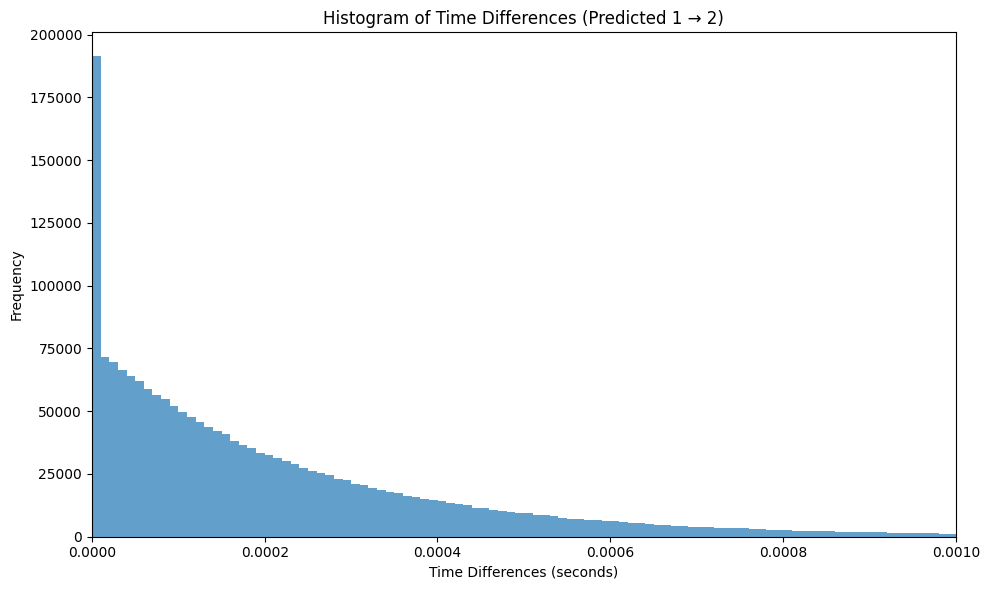

In [22]:
# Plot histogram for predicted differences (filtering to <= threshold and non-zero)
filtered_diffs = [x for x in flattened_diffs if x <= threshold and x != 0]
plot_histogram(filtered_diffs,
               title='Histogram of Time Differences (Predicted 1 → 2)',
               xlabel='Time Differences (seconds)',
               ylabel='Frequency',
               xlim=(0, 0.001))

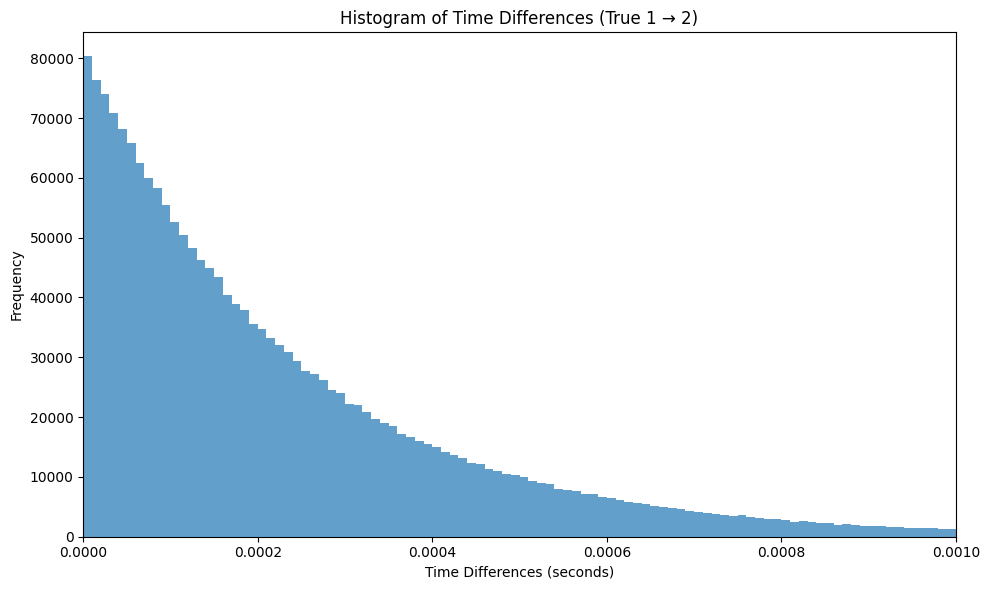

In [23]:
# Plot histogram for ground truth differences
filtered_diffs_real = [x for x in flattened_diffs_real if x <= threshold and x != 0]
plot_histogram(filtered_diffs_real,
               title='Histogram of Time Differences (True 1 → 2)',
               xlabel='Time Differences (seconds)',
               ylabel='Frequency',
               xlim=(0, 0.001))

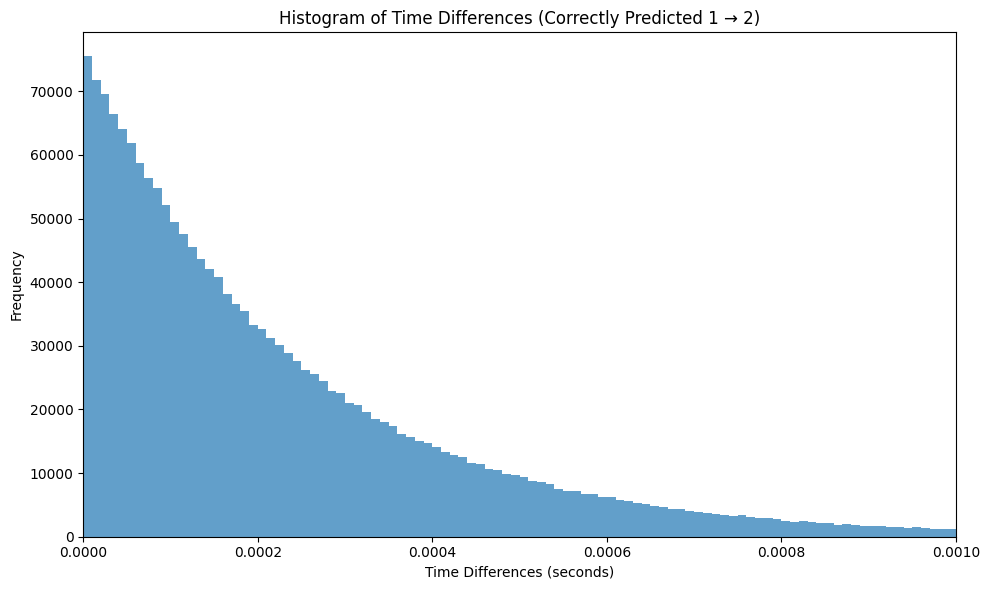

In [24]:
# Calculate correctly predicted time differences
correct_diffs = calculate_correct_time_differences(rp.X_seq_test, y_pred_classes, y_test_classes, event_pair_1_2)
flattened_correct_diffs = flatten_differences(correct_diffs)
filtered_correct_diffs = [x for x in flattened_correct_diffs if x <= threshold and x != 0]
plot_histogram(filtered_correct_diffs,
               title='Histogram of Time Differences (Correctly Predicted 1 → 2)',
               xlabel='Time Differences (seconds)',
               ylabel='Frequency',
               xlim=(0, 0.001))

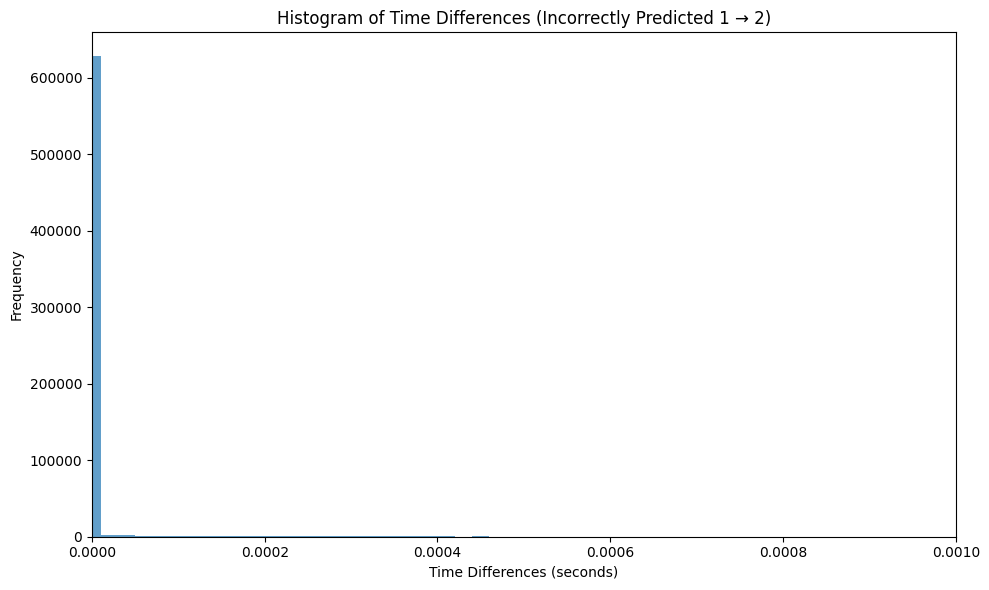

In [25]:
# Calculate incorrectly predicted time differences
incorrect_diffs = calculate_incorrect_time_differences(rp.X_seq_test, y_pred_classes, y_test_classes, event_pair_1_2)
flattened_incorrect_diffs = flatten_differences(incorrect_diffs)
filtered_incorrect_diffs = [x for x in flattened_incorrect_diffs if x <= threshold and x != 0]
plot_histogram(filtered_incorrect_diffs,
               title='Histogram of Time Differences (Incorrectly Predicted 1 → 2)',
               xlabel='Time Differences (seconds)',
               ylabel='Frequency',
               xlim=(0, 0.001))

# Bi212 (Raw Pred)

In [26]:
# For events 4 and 5:
event_pair_4_5 = (4, 5)

# Calculate time differences for predicted sequences (all pairs) for events 4 → 5
all_result_diffs_4_5 = calculate_time_differences_for_pair(rp.X_seq_test, y_pred_classes, event_pair_4_5)
flattened_diffs_4_5 = flatten_differences(all_result_diffs_4_5)

In [27]:
# Apply threshold if needed
threshold = 0.01
values_above_threshold_4_5 = [x for x in flattened_diffs_4_5 if x > threshold]
print("Predicted values greater than", threshold, "for events 4 → 5:", values_above_threshold_4_5)


Predicted values greater than 0.01 for events 4 → 5: [0.9535638988018036, 0.0387692004442215, 0.20081719756126404, 0.9954116940498352, 2.5195946022868156, 0.7491976022720337, 1.0599147975444794, 1.0033223032951355, 16.092430397868156, 1.2990078926086426, 67.67025411128998, 0.11387999355792999, 0.32228970527648926, 1.7069135010242462, 0.379202201962471, 1.0033223032951355, 0.19700650870800018, 0.7949486970901489, 0.11387999355792999, 1.6180766001343727, 0.2362803965806961, 0.4526064991950989, 0.8832554966211319, 44.46738559752703, 0.0263139009475708, 2.7353166043758392, 0.7951259016990662, 0.033285900950431824, 0.0263139009475708, 1.736848697066307, 0.2935764938592911, 1.8848707005381584, 0.6902657002210617, 2.906490594148636, 0.0263139009475708, 0.033285900950431824, 1.0033223032951355, 0.0387692004442215, 1.1543389111757278, 0.8832554966211319, 0.19700650870800018, 1.0033223032951355, 0.033285900950431824, 0.0263139009475708, 0.6318366080522537, 1.81666399538517, 2.3416202068328857, 0

In [28]:
# Similarly, for the ground truth for events 4 → 5:
all_result_diffs_real_4_5 = calculate_time_differences_for_pair(rp.X_seq_test, y_test_classes, event_pair_4_5)
flattened_diffs_real_4_5 = flatten_differences(all_result_diffs_real_4_5)
values_above_threshold_real_4_5 = [x for x in flattened_diffs_real_4_5 if x > threshold]
print("Ground truth values greater than", threshold, "for events 4 → 5:", values_above_threshold_real_4_5)

Ground truth values greater than 0.01 for events 4 → 5: [16.092430397868156, 27.509696394205093, 27.509696394205093, 16.092430397868156]


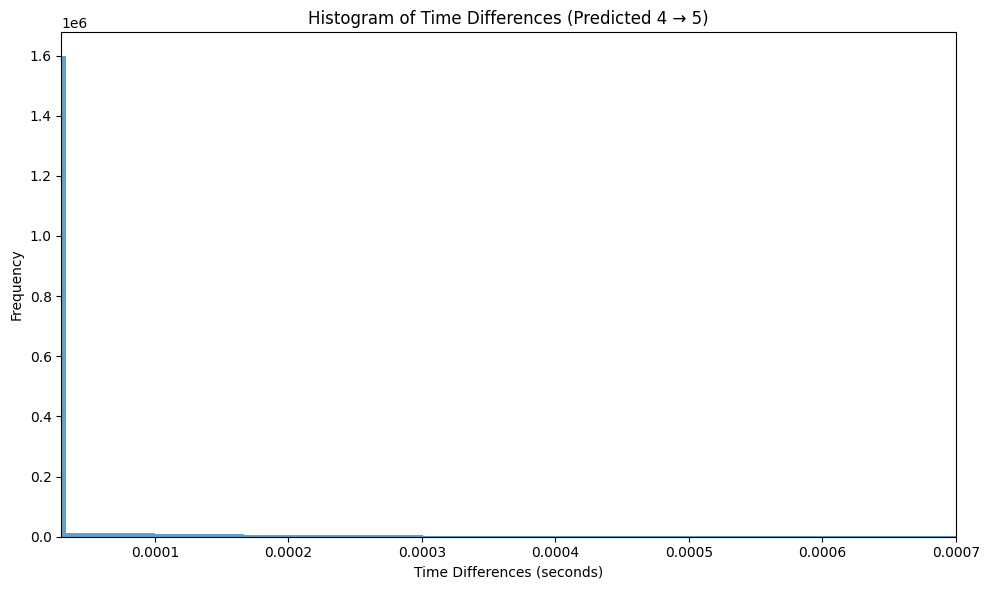

In [29]:
# Plot histogram for predicted differences (filtering to <= threshold and non-zero) for events 4 → 5
filtered_diffs_4_5 = [x for x in flattened_diffs_4_5 if x <= threshold and x != 0]
plot_histogram(filtered_diffs_4_5,
               title='Histogram of Time Differences (Predicted 4 → 5)',
               xlabel='Time Differences (seconds)',
               ylabel='Frequency',
               xlim=(0.00003, 0.0007))

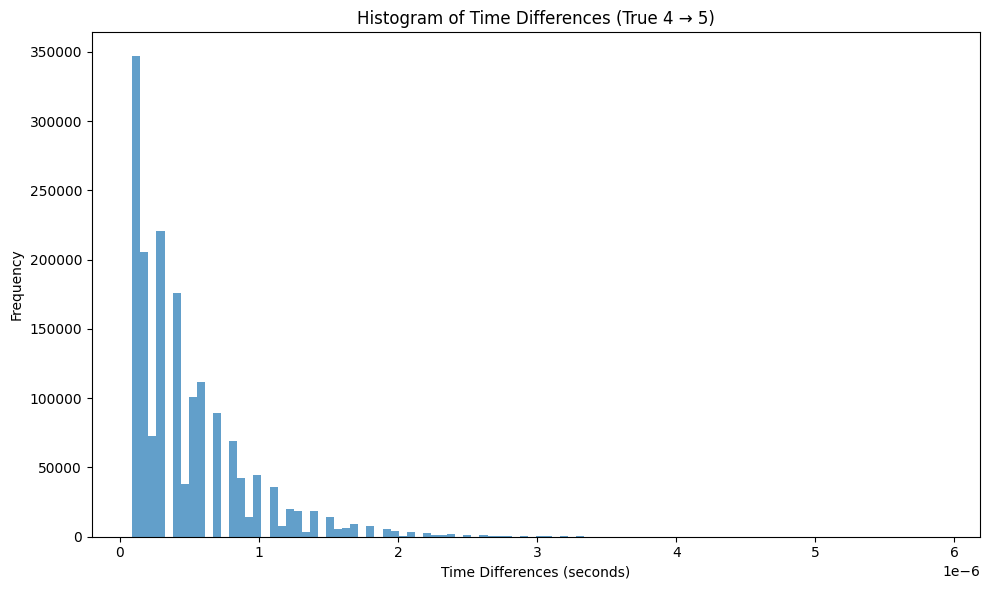

In [30]:
# Plot histogram for ground truth differences for events 4 → 5
filtered_diffs_real_4_5 = [x for x in flattened_diffs_real_4_5 if x <= threshold and x != 0]
plot_histogram(filtered_diffs_real_4_5,
               title='Histogram of Time Differences (True 4 → 5)',
               xlabel='Time Differences (seconds)',
               ylabel='Frequency')

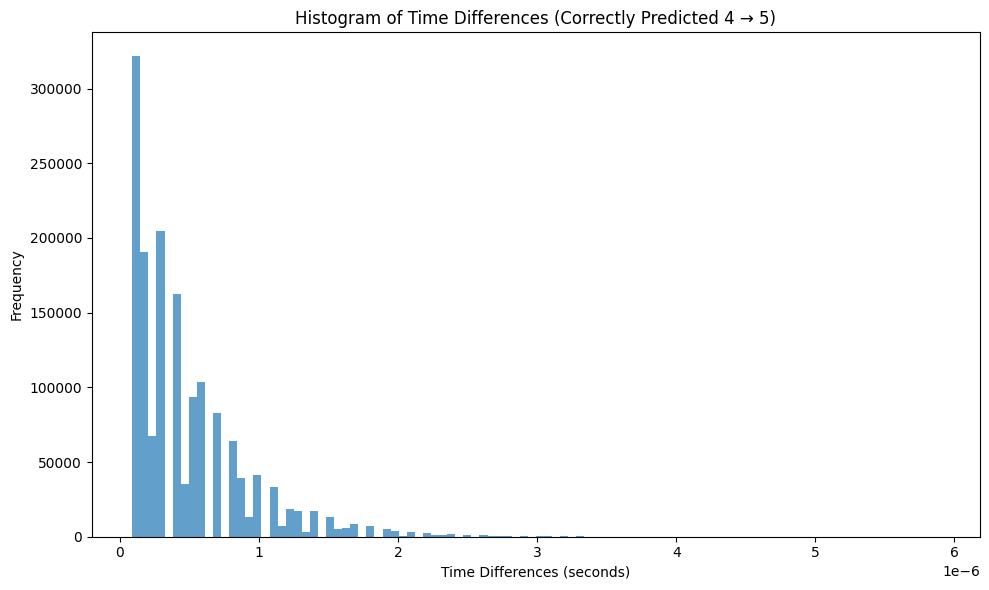

In [31]:
# Calculate correctly predicted time differences for events 4 → 5
correct_diffs_4_5 = calculate_correct_time_differences(rp.X_seq_test, y_pred_classes, y_test_classes, event_pair_4_5)
flattened_correct_diffs_4_5 = flatten_differences(correct_diffs_4_5)
filtered_correct_diffs_4_5 = [x for x in flattened_correct_diffs_4_5 if x <= threshold and x != 0]
plot_histogram(filtered_correct_diffs_4_5,
               title='Histogram of Time Differences (Correctly Predicted 4 → 5)',
               xlabel='Time Differences (seconds)',
               ylabel='Frequency')

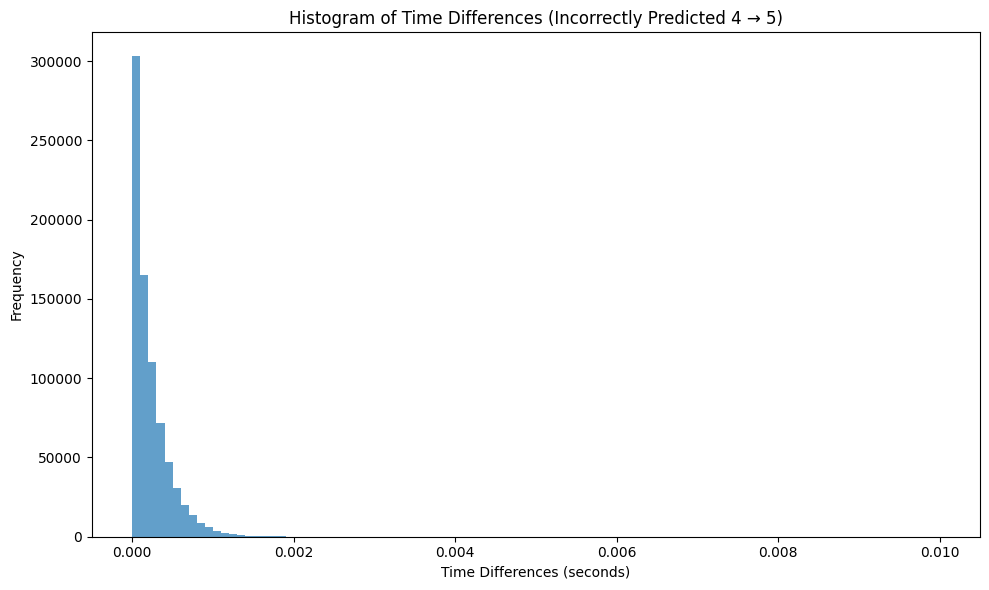

In [32]:
# Calculate incorrectly predicted time differences for events 4 → 5
incorrect_diffs_4_5 = calculate_incorrect_time_differences(rp.X_seq_test, y_pred_classes, y_test_classes, event_pair_4_5)
flattened_incorrect_diffs_4_5 = flatten_differences(incorrect_diffs_4_5)
filtered_incorrect_diffs_4_5 = [x for x in flattened_incorrect_diffs_4_5 if x <= threshold and x != 0]
plot_histogram(filtered_incorrect_diffs_4_5,
               title='Histogram of Time Differences (Incorrectly Predicted 4 → 5)',
               xlabel='Time Differences (seconds)',
               ylabel='Frequency')

# PAIR WISE CLASSIFICATION

In [33]:
def enforce_pairs_with_background(y_pred, background_class=0):
    """
    Enforce valid (1→2) and (4→5) pairs in the predicted sequences,
    reassigning any unpaired events to a background class.

    Parameters
    ----------
    y_pred : array-like
        Predicted labels. It can be:
         - a 1D array of integers (a single sequence),
         - a 2D array of shape (num_sequences, sequence_length), or
         - a 3D array of shape (num_sequences, sequence_length, num_classes),
           in which case predictions are converted via np.argmax along the last axis.
    background_class : int, optional
        The class to assign for unpaired events (default is 0).

    Returns
    -------
    corrected_preds : np.ndarray
        An array of corrected predictions with the same structure as the input.
    """
    # Convert input to a NumPy array (if it isn't already)
    y_pred = np.asarray(y_pred)
    
    # Convert to label indices if needed.
    if y_pred.ndim == 3:
        # Shape is (num_sequences, sequence_length, num_classes)
        y_pred_labels = np.argmax(y_pred, axis=-1)
    elif y_pred.ndim == 2:
        # Already shape (num_sequences, sequence_length)
        y_pred_labels = y_pred
    elif y_pred.ndim == 1:
        # A single sequence; wrap it into a 2D array for uniform processing.
        y_pred_labels = y_pred[None, :]  # Shape (1, sequence_length)
    else:
        raise ValueError("Unsupported input shape: expected 1D, 2D, or 3D array.")
    
    corrected_preds = []  # List to hold corrected predictions for each sequence

    # Process each sequence individually
    for seq in y_pred_labels:
        corrected_seq = []
        i = 0
        while i < len(seq):
            # Handle potential pair for classes 1 and 2
            if seq[i] == 1:
                if i + 1 < len(seq) and seq[i + 1] == 2:
                    corrected_seq.extend([1, 2])
                    i += 2  # Skip the pair
                else:
                    corrected_seq.append(background_class)
                    i += 1
            elif seq[i] == 2:
                # If class 2 is not preceded by 1, reassign it.
                if i == 0 or seq[i - 1] != 1:
                    corrected_seq.append(background_class)
                else:
                    corrected_seq.append(2)
                i += 1
            # Handle potential pair for classes 4 and 5
            elif seq[i] == 4:
                if i + 1 < len(seq) and seq[i + 1] == 5:
                    corrected_seq.extend([4, 5])
                    i += 2
                else:
                    corrected_seq.append(background_class)
                    i += 1
            elif seq[i] == 5:
                if i == 0 or seq[i - 1] != 4:
                    corrected_seq.append(background_class)
                else:
                    corrected_seq.append(5)
                i += 1
            else:
                # For any other class, keep it as is.
                corrected_seq.append(seq[i])
                i += 1
        corrected_preds.append(corrected_seq)
    
    corrected_preds = np.array(corrected_preds)
    
    # If the input was a single sequence (1D), return a 1D array.
    if corrected_preds.shape[0] == 1:
        return corrected_preds[0]
    return corrected_preds

In [34]:
y_pred_pair = enforce_pairs_with_background(y_pred_classes)

In [35]:
y_pred_pair.shape

(1288605, 10)

In [36]:
y_pred_pair_flat = y_pred_pair.reshape(-1)

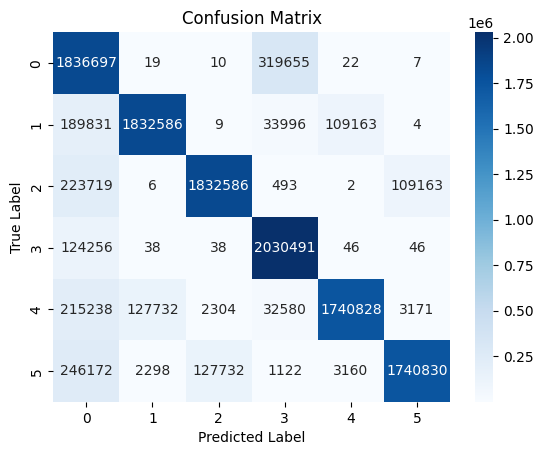

In [37]:
# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test_classes_flat, y_pred_pair_flat)

# Plot the confusion matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [38]:
result_pair = signal_detection_metrics(y_test_classes_flat, y_pred_pair_flat, [1, 2, 4, 5])
print(result_pair)


Results for class 1:
  - Total events classified as this class: 1962679
  - Percentage of actual signal events detected: 84.62%
  - Percentage of detected signal accuracy: 93.37%
  - Misclassified as other classes:
    - Class 4: 6.51%
    - Class 3: 0.00%
    - Class 5: 0.12%
    - Class 2: 0.00%
    - Class 0: 0.00%

Results for class 2:
  - Total events classified as this class: 1962679
  - Percentage of actual signal events detected: 84.61%
  - Percentage of detected signal accuracy: 93.37%
  - Misclassified as other classes:
    - Class 5: 6.51%
    - Class 3: 0.00%
    - Class 4: 0.12%
    - Class 1: 0.00%
    - Class 0: 0.00%

Results for class 4:
  - Total events classified as this class: 1853221
  - Percentage of actual signal events detected: 82.04%
  - Percentage of detected signal accuracy: 93.94%
  - Misclassified as other classes:
    - Class 1: 5.89%
    - Class 5: 0.17%
    - Class 0: 0.00%
    - Class 3: 0.00%
    - Class 2: 0.00%

Results for class 5:
  - Total event

In [39]:
classification = classification_report(y_test_classes_flat, y_pred_pair_flat)
print("Classification Report:\n")
print(classification)

Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.85      0.74   2156410
           1       0.93      0.85      0.89   2165589
           2       0.93      0.85      0.89   2165969
           3       0.84      0.94      0.89   2154915
           4       0.94      0.82      0.88   2121853
           5       0.94      0.82      0.88   2121314

    accuracy                           0.85  12886050
   macro avg       0.87      0.85      0.86  12886050
weighted avg       0.87      0.85      0.86  12886050



## Bi214 (Pair)

In [40]:
# For events 1 and 2:
event_pair_1_2 = (1, 2)

In [41]:
# Calculate time differences for predicted sequences (all pairs)
all_result_diffs = calculate_time_differences_for_pair(rp.X_seq_test, y_pred_pair, event_pair_1_2)
flattened_diffs = flatten_differences(all_result_diffs)

In [42]:
# Apply threshold if needed
threshold = 0.001
values_above_threshold = [x for x in flattened_diffs if x > threshold]
print("Predicted values greater than", threshold, ":", values_above_threshold)

Predicted values greater than 0.001 : [0.0014021992683410645, 0.0014491006731987, 0.0016923993825912476, 0.0010488927364349365, 0.0011337026953697205, 0.001220904290676117, 0.0013361945748329163, 0.0011233985424041748, 0.001046702265739441, 0.0010794028639793396, 0.0013380944728851318, 0.001010105013847351, 0.001354992389678955, 0.0012397989630699158, 0.0012561976909637451, 0.0011797994375228882, 0.0010315030813217163, 0.0010160058736801147, 0.001041896641254425, 0.0010137036442756653, 0.0012058019638061523, 0.5466848015785217, 0.0011689066886901855, 0.0010104924440383911, 0.0010986998677253723, 0.0010361969470977783, 0.0016125887632369995, 0.0010151118040084839, 0.0010542050004005432, 0.0013686120510101318, 0.0013836026191711426, 0.0015624016523361206, 0.0011214986443519592, 0.0017047002911567688, 0.0011684000492095947, 0.0013274997472763062, 0.0011559054255485535, 0.0010123029351234436, 0.0011618956923484802, 0.0010084062814712524, 0.0011693984270095825, 0.0011250004172325134, 0.0012

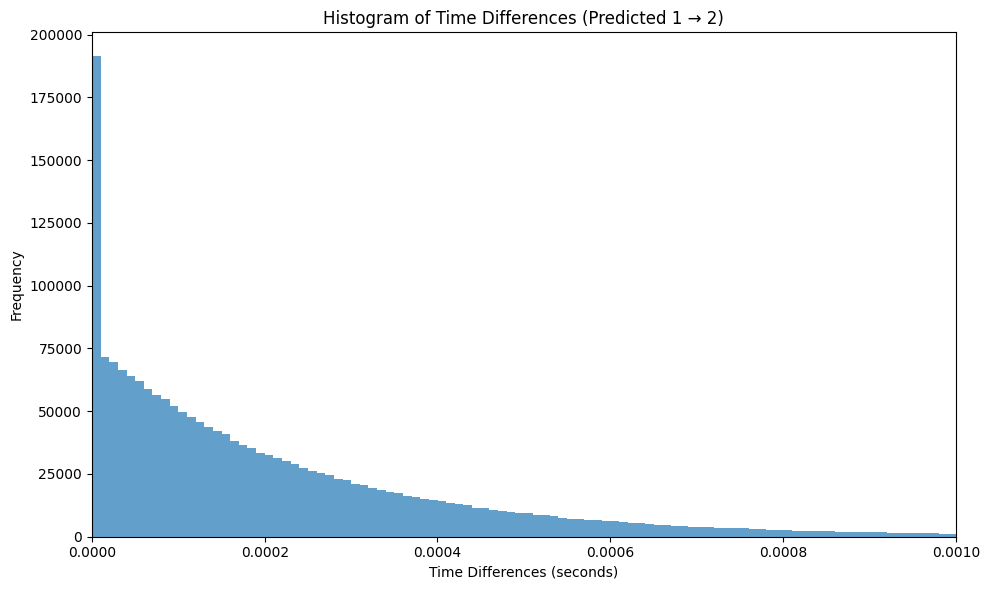

In [43]:
# Plot histogram for predicted differences (filtering to <= threshold and non-zero)
filtered_diffs = [x for x in flattened_diffs if x <= threshold and x != 0]
plot_histogram(filtered_diffs,
               title='Histogram of Time Differences (Predicted 1 → 2)',
               xlabel='Time Differences (seconds)',
               ylabel='Frequency',
               xlim=(0, 0.001))

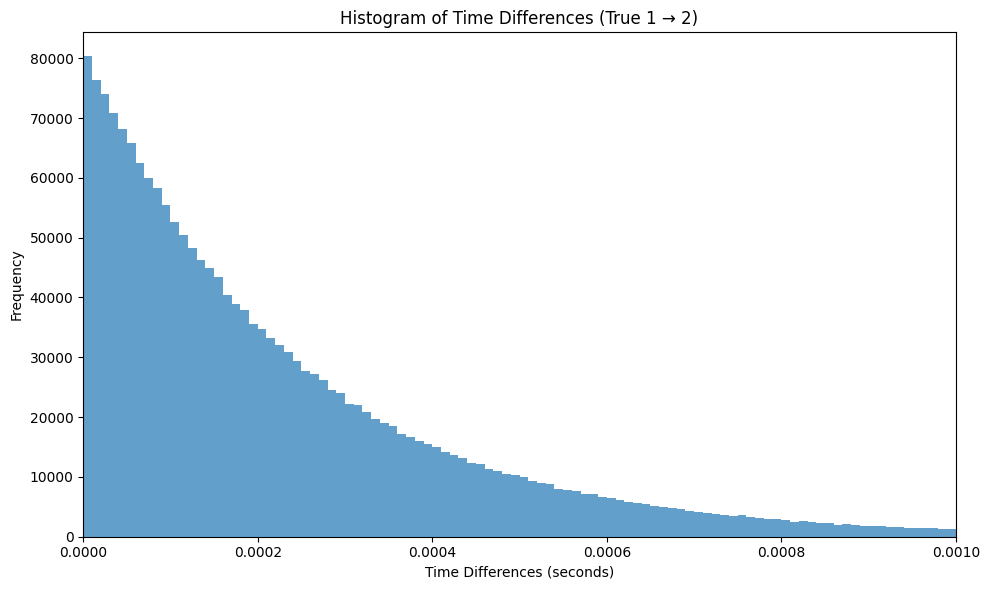

In [44]:
# Plot histogram for ground truth differences
filtered_diffs_real = [x for x in flattened_diffs_real if x <= threshold and x != 0]
plot_histogram(filtered_diffs_real,
               title='Histogram of Time Differences (True 1 → 2)',
               xlabel='Time Differences (seconds)',
               ylabel='Frequency',
               xlim=(0, 0.001))

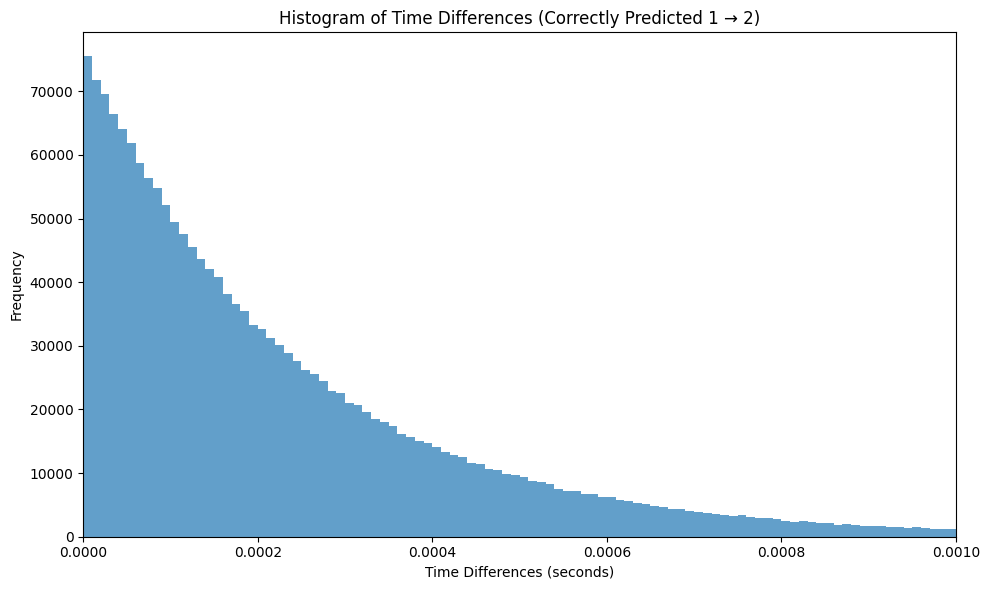

In [45]:
# Calculate correctly predicted time differences
correct_diffs = calculate_correct_time_differences(rp.X_seq_test, y_pred_pair, y_test_classes, event_pair_1_2)
flattened_correct_diffs = flatten_differences(correct_diffs)
filtered_correct_diffs = [x for x in flattened_correct_diffs if x <= threshold and x != 0]
plot_histogram(filtered_correct_diffs,
               title='Histogram of Time Differences (Correctly Predicted 1 → 2)',
               xlabel='Time Differences (seconds)',
               ylabel='Frequency',
               xlim=(0, 0.001))

In [65]:
threshold= 0.0001

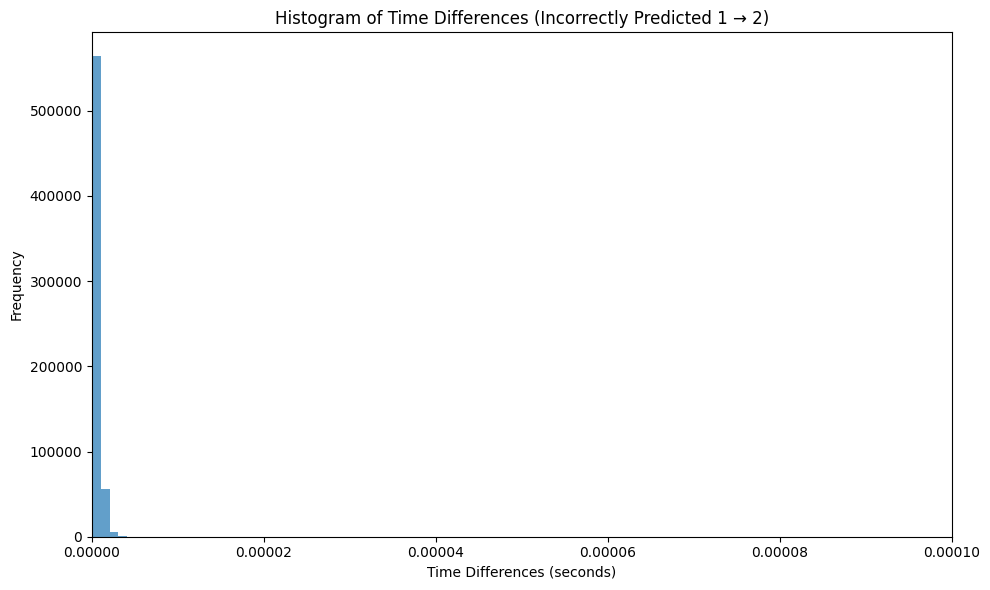

In [66]:
# Calculate incorrectly predicted time differences
incorrect_diffs = calculate_incorrect_time_differences(rp.X_seq_test, y_pred_pair, y_test_classes, event_pair_1_2)
flattened_incorrect_diffs = flatten_differences(incorrect_diffs)
filtered_incorrect_diffs = [x for x in flattened_incorrect_diffs if x <= threshold and x != 0]
plot_histogram(filtered_incorrect_diffs,
               title='Histogram of Time Differences (Incorrectly Predicted 1 → 2)',
               xlabel='Time Differences (seconds)',
               ylabel='Frequency',
               xlim=(0, 0.0001))

## Bi212 (Pair)

In [47]:
# For events 4 and 5:
event_pair_4_5 = (4, 5)

In [48]:
# Calculate time differences for predicted sequences (all pairs) for events 4 → 5
all_result_diffs_4_5 = calculate_time_differences_for_pair(rp.X_seq_test, y_pred_pair, event_pair_4_5)
flattened_diffs_4_5 = flatten_differences(all_result_diffs_4_5)

In [49]:
# Apply threshold if needed
threshold = 0.01
values_above_threshold_4_5 = [x for x in flattened_diffs_4_5 if x > threshold]
print("Predicted values greater than", threshold, "for events 4 → 5:", values_above_threshold_4_5)


Predicted values greater than 0.01 for events 4 → 5: [0.9535638988018036, 0.0387692004442215, 0.20081719756126404, 0.9954116940498352, 2.5195946022868156, 0.7491976022720337, 1.0599147975444794, 1.0033223032951355, 16.092430397868156, 1.2990078926086426, 67.67025411128998, 0.11387999355792999, 0.32228970527648926, 1.7069135010242462, 0.379202201962471, 1.0033223032951355, 0.19700650870800018, 0.7949486970901489, 0.11387999355792999, 1.6180766001343727, 0.2362803965806961, 0.4526064991950989, 0.8832554966211319, 44.46738559752703, 0.0263139009475708, 2.7353166043758392, 0.7951259016990662, 0.033285900950431824, 0.0263139009475708, 1.736848697066307, 0.2935764938592911, 1.8848707005381584, 0.6902657002210617, 2.906490594148636, 0.0263139009475708, 0.033285900950431824, 1.0033223032951355, 0.0387692004442215, 1.1543389111757278, 0.8832554966211319, 0.19700650870800018, 1.0033223032951355, 0.033285900950431824, 0.0263139009475708, 0.6318366080522537, 1.81666399538517, 2.3416202068328857, 0

In [67]:
threshold= 6e-6

In [68]:
# Plot histogram for predicted differences (filtering to <= threshold and non-zero) for events 4 → 5
filtered_diffs_4_5 = [x for x in flattened_diffs_4_5 if x <= threshold and x != 0]

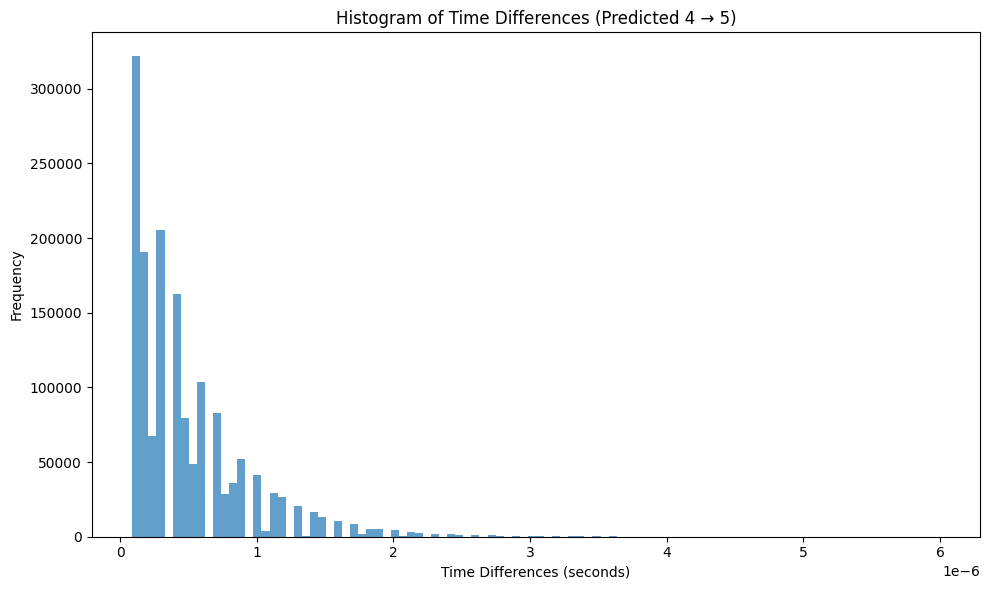

In [70]:
plot_histogram(filtered_diffs_4_5,
               title='Histogram of Time Differences (Predicted 4 → 5)',
               xlabel='Time Differences (seconds)',
               ylabel='Frequency',
               #xlim=(0, 0.0001),
               #xlim = (0.00003, 0.0007),
               #ylim=(0, 80000)
               )

In [54]:
# Plot histogram for ground truth differences for events 4 → 5
filtered_diffs_real_4_5 = [x for x in flattened_diffs_real_4_5 if x <= threshold and x != 0]

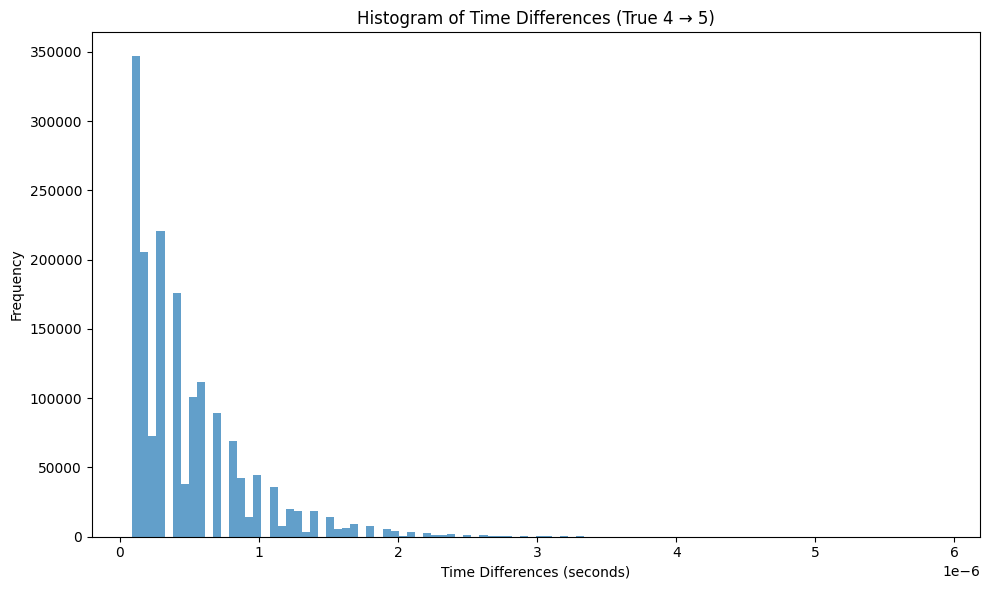

In [55]:
plot_histogram(filtered_diffs_real_4_5,
               title='Histogram of Time Differences (True 4 → 5)',
               xlabel='Time Differences (seconds)',
               ylabel='Frequency')

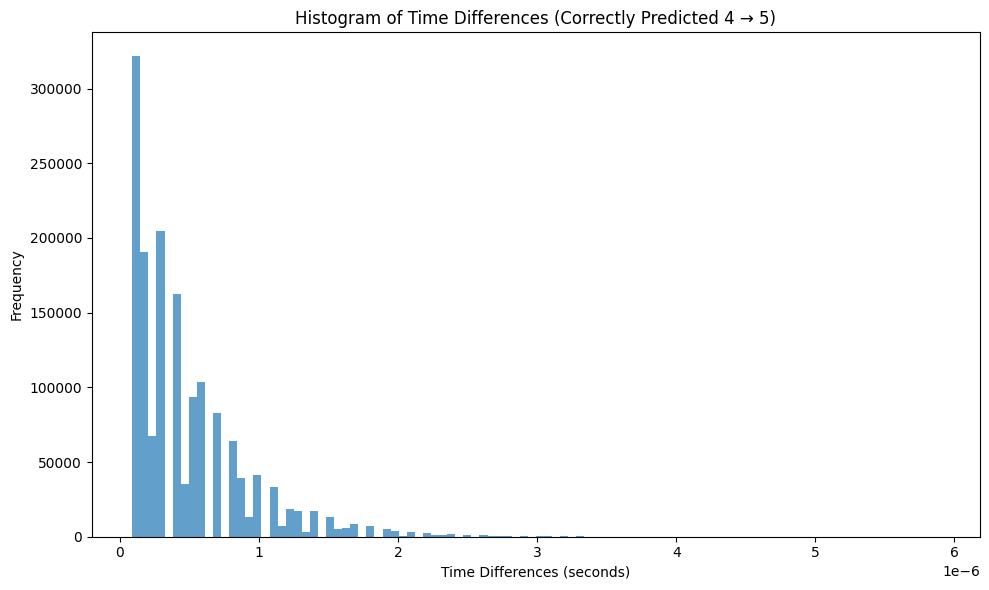

In [52]:
# Calculate correctly predicted time differences for events 4 → 5
correct_diffs_4_5 = calculate_correct_time_differences(rp.X_seq_test, y_pred_pair, y_test_classes, event_pair_4_5)
flattened_correct_diffs_4_5 = flatten_differences(correct_diffs_4_5)
filtered_correct_diffs_4_5 = [x for x in flattened_correct_diffs_4_5 if x <= threshold and x != 0]
plot_histogram(filtered_correct_diffs_4_5,
               title='Histogram of Time Differences (Correctly Predicted 4 → 5)',
               xlabel='Time Differences (seconds)',
               ylabel='Frequency')

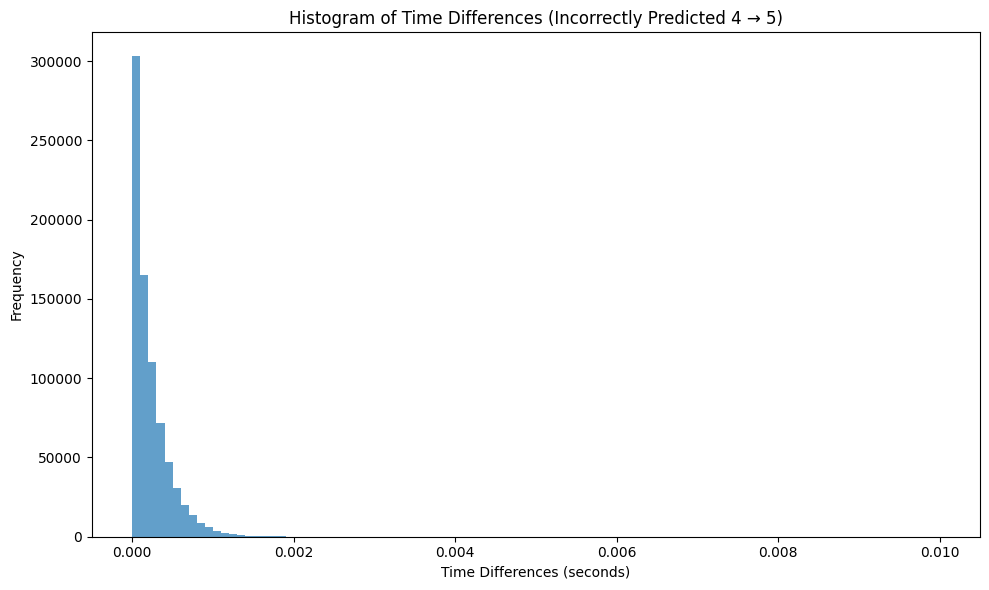

In [53]:
# Calculate incorrectly predicted time differences for events 4 → 5
incorrect_diffs_4_5 = calculate_incorrect_time_differences(rp.X_seq_test, y_pred_pair, y_test_classes, event_pair_4_5)
flattened_incorrect_diffs_4_5 = flatten_differences(incorrect_diffs_4_5)
filtered_incorrect_diffs_4_5 = [x for x in flattened_incorrect_diffs_4_5 if x <= threshold and x != 0]
plot_histogram(filtered_incorrect_diffs_4_5,
               title='Histogram of Time Differences (Incorrectly Predicted 4 → 5)',
               xlabel='Time Differences (seconds)',
               ylabel='Frequency') 